In [5]:
import pandas as pd
from pathlib import Path

DATA_DIR = Path("../data")
METRICS_DIR = DATA_DIR / "metrics"
LOGS_DIR = DATA_DIR / "logs"

In [6]:
cart = pd.read_csv(METRICS_DIR / "cart-service.csv", parse_dates=["timestamp"])
order = pd.read_csv(METRICS_DIR / "order-service.csv", parse_dates=["timestamp"])
payment = pd.read_csv(METRICS_DIR / "payment-service.csv", parse_dates=["timestamp"])
api = pd.read_csv(METRICS_DIR / "api-gateway.csv", parse_dates=["timestamp"])
product = pd.read_csv(METRICS_DIR / "product-service.csv", parse_dates=["timestamp"])

In [7]:
print("cart:", cart.shape)
print("order:", order.shape)
print("payment:", payment.shape)
print("api:", api.shape)
print("product:", product.shape)

cart: (2820, 9)
order: (2820, 5)
payment: (2820, 5)
api: (2820, 7)
product: (2820, 5)


In [4]:
cart.head()

,timestamp,memory_usage_bytes,memory_limit_bytes,cpu_usage_percent,http_requests_per_sec,http_p99_latency_ms,http_5xx_rate,jvm_gc_pause_ms_avg,container_restart_count
0,2026-06-01 00:00:00+00:00,431525846,2147483648,20.57,30.82,43.4,1.97,51.1,0
1,2026-06-01 00:00:30+00:00,449833946,2147483648,18.08,47.26,63.0,0.00,53.4,0
2,2026-06-01 00:01:00+00:00,434288391,2147483648,16.60,44.16,116.0,0.43,67.7,0
3,2026-06-01 00:01:30+00:00,378756116,2147483648,30.04,35.49,52.1,0.52,54.4,0
4,2026-06-01 00:02:00+00:00,457694217,2147483648,36.43,26.63,41.8,2.00,52.5,0


In [8]:
for name, df in {
    "cart": cart,
    "order": order,
    "payment": payment,
    "api": api,
    "product": product
}.items():
    print("\n", name)
    print(df.columns.tolist())


 cart
['timestamp', 'memory_usage_bytes', 'memory_limit_bytes', 'cpu_usage_percent', 'http_requests_per_sec', 'http_p99_latency_ms', 'http_5xx_rate', 'jvm_gc_pause_ms_avg', 'container_restart_count']

 order
['timestamp', 'http_requests_per_sec', 'http_p99_latency_ms', 'http_5xx_rate', 'upstream_timeout_rate']

 payment
['timestamp', 'http_requests_per_sec', 'http_p99_latency_ms', 'http_5xx_rate', 'upstream_timeout_rate']

 api
['timestamp', 'http_requests_per_sec', 'http_p99_latency_ms', 'http_5xx_rate', 'cart_upstream_error_rate', 'product_upstream_error_rate', 'active_connections']

 product
['timestamp', 'http_requests_per_sec', 'http_p99_latency_ms', 'cpu_usage_percent', 'http_5xx_rate']


In [9]:
for name,df in {
    "cart": cart,
    "order": order,
    "payment": payment,
    "api": api,
    "product": product
}.items():
    print("\n", name)
    print("Start:", df["timestamp"].min())
    print("End:", df["timestamp"].max())



 cart
Start: 2026-06-01 00:00:00+00:00
End: 2026-06-01 23:59:30+00:00

 order
Start: 2026-06-01 00:00:00+00:00
End: 2026-06-01 23:59:30+00:00

 payment
Start: 2026-06-01 00:00:00+00:00
End: 2026-06-01 23:59:30+00:00

 api
Start: 2026-06-01 00:00:00+00:00
End: 2026-06-01 23:59:30+00:00

 product
Start: 2026-06-01 00:00:00+00:00
End: 2026-06-01 23:59:30+00:00


In [7]:
for name, df in {
    "cart": cart,
    "order": order,
    "payment": payment,
    "api": api,
    "product": product
}.items():
    print("\n", name)
    print(df.isna().sum())


 cart
timestamp                  0
memory_usage_bytes         0
memory_limit_bytes         0
cpu_usage_percent          0
http_requests_per_sec      0
http_p99_latency_ms        0
http_5xx_rate              0
jvm_gc_pause_ms_avg        0
container_restart_count    0
dtype: int64

 order
timestamp                0
http_requests_per_sec    0
http_p99_latency_ms      0
http_5xx_rate            0
upstream_timeout_rate    0
dtype: int64

 payment
timestamp                0
http_requests_per_sec    0
http_p99_latency_ms      0
http_5xx_rate            0
upstream_timeout_rate    0
dtype: int64

 api
timestamp                      0
http_requests_per_sec          0
http_p99_latency_ms            0
http_5xx_rate                  0
cart_upstream_error_rate       0
product_upstream_error_rate    0
active_connections             0
dtype: int64

 product
timestamp                0
http_requests_per_sec    0
http_p99_latency_ms      0
cpu_usage_percent        0
http_5xx_rate            0
dtype: int

In [8]:
cart["timestamp"].diff().value_counts().head()

timestamp
0 days 00:00:30    2818
0 days 00:30:30       1
Name: count, dtype: int64

In [9]:
for name, df in {
    "cart": cart,
    "order": order,
    "payment": payment,
    "api": api,
    "product": product
}.items():
    print("\n", name)
    print(df["timestamp"].diff().value_counts().head())


 cart
timestamp
0 days 00:00:30    2818
0 days 00:30:30       1
Name: count, dtype: int64

 order
timestamp
0 days 00:00:30    2818
0 days 00:30:30       1
Name: count, dtype: int64

 payment
timestamp
0 days 00:00:30    2818
0 days 00:30:30       1
Name: count, dtype: int64

 api
timestamp
0 days 00:00:30    2818
0 days 00:30:30       1
Name: count, dtype: int64

 product
timestamp
0 days 00:00:30    2818
0 days 00:30:30       1
Name: count, dtype: int64


Loaded 5 metric files successfully:
- cart-service
- order-service
- payment-service
- api-gateway
- product-service

All files contain timestamped metrics at 30-second intervals.
No missing values were found.
The data covers the 24-hour incident window ending near the alert time.

In [10]:
cart.shape
cart.head()
cart["timestamp"].min(), cart["timestamp"].max()
cart.isna().sum()

timestamp                  0
memory_usage_bytes         0
memory_limit_bytes         0
cpu_usage_percent          0
http_requests_per_sec      0
http_p99_latency_ms        0
http_5xx_rate              0
jvm_gc_pause_ms_avg        0
container_restart_count    0
dtype: int64

In [11]:
print("start:", cart["timestamp"].min())
print("end:", cart["timestamp"].max())
print("rows:", len(cart))

start: 2026-06-01 00:00:00+00:00
end: 2026-06-01 23:59:30+00:00
rows: 2820


In [12]:
cart["timestamp"].diff().value_counts().head()

timestamp
0 days 00:00:30    2818
0 days 00:30:30       1
Name: count, dtype: int64

In [13]:
cart["diff"] = cart["timestamp"].diff()

cart[cart["diff"] > pd.Timedelta(seconds=30)][
    ["timestamp", "diff"]
]

,timestamp,diff
1380,2026-06-01 12:00:00+00:00,0 days 00:30:30


In [14]:
gap_row = cart[cart["diff"] > pd.Timedelta(seconds=30)].index[0]

cart.loc[gap_row-3:gap_row+3, ["timestamp", "memory_usage_bytes", "http_5xx_rate", "jvm_gc_pause_ms_avg", "container_restart_count", "diff"]]

,timestamp,memory_usage_bytes,http_5xx_rate,jvm_gc_pause_ms_avg,container_restart_count,diff
1377,2026-06-01 11:28:30+00:00,340031292,0.60,29.0,0,0 days 00:00:30
1378,2026-06-01 11:29:00+00:00,326692497,1.16,31.9,0,0 days 00:00:30
1379,2026-06-01 11:29:30+00:00,310035066,0.00,29.7,0,0 days 00:00:30
1380,2026-06-01 12:00:00+00:00,435964799,0.00,64.8,0,0 days 00:30:30
1381,2026-06-01 12:00:30+00:00,384077168,0.00,58.9,0,0 days 00:00:30
1382,2026-06-01 12:01:00+00:00,452340640,1.02,74.0,0,0 days 00:00:30
1383,2026-06-01 12:01:30+00:00,484407659,1.59,53.2,0,0 days 00:00:30


Cart-service metrics mostly use a 30-second interval, but there is one 30-minute gap. This gap should be considered during anomaly detection because rolling-window methods may be affected near the missing interval.

In [15]:
cart["diff"] = cart["timestamp"].diff()

gap = cart[cart["diff"] > pd.Timedelta(seconds=30)]

gap[["timestamp", "diff"]]

,timestamp,diff
1380,2026-06-01 12:00:00+00:00,0 days 00:30:30


In [16]:
gap_row = gap.index[0]

cart.loc[
    gap_row-3:gap_row+3,
    [
        "timestamp",
        "memory_usage_bytes",
        "http_p99_latency_ms",
        "http_5xx_rate",
        "jvm_gc_pause_ms_avg",
        "container_restart_count",
        "diff"
    ]
]

,timestamp,memory_usage_bytes,http_p99_latency_ms,http_5xx_rate,jvm_gc_pause_ms_avg,container_restart_count,diff
1377,2026-06-01 11:28:30+00:00,340031292,57.5,0.60,29.0,0,0 days 00:00:30
1378,2026-06-01 11:29:00+00:00,326692497,52.2,1.16,31.9,0,0 days 00:00:30
1379,2026-06-01 11:29:30+00:00,310035066,30.0,0.00,29.7,0,0 days 00:00:30
1380,2026-06-01 12:00:00+00:00,435964799,44.1,0.00,64.8,0,0 days 00:30:30
1381,2026-06-01 12:00:30+00:00,384077168,43.9,0.00,58.9,0,0 days 00:00:30
1382,2026-06-01 12:01:00+00:00,452340640,71.1,1.02,74.0,0,0 days 00:00:30
1383,2026-06-01 12:01:30+00:00,484407659,30.0,1.59,53.2,0,0 days 00:00:30


1. Có 1 gap trong cart-service metrics.
2. Gap dài 30 phút 30 giây.
3. Gap nằm ở timestamp nào.

In [17]:
dfs = {
    "cart": cart,
    "order": order,
    "payment": payment,
    "api": api,
    "product": product
}

for name, df in dfs.items():
    df["diff"] = df["timestamp"].diff()
    print("\n", name)
    print(df["diff"].value_counts().head())


 cart
diff
0 days 00:00:30    2818
0 days 00:30:30       1
Name: count, dtype: int64

 order
diff
0 days 00:00:30    2818
0 days 00:30:30       1
Name: count, dtype: int64

 payment
diff
0 days 00:00:30    2818
0 days 00:30:30       1
Name: count, dtype: int64

 api
diff
0 days 00:00:30    2818
0 days 00:30:30       1
Name: count, dtype: int64

 product
diff
0 days 00:00:30    2818
0 days 00:30:30       1
Name: count, dtype: int64


In [18]:
gap[["timestamp", "diff"]]

,timestamp,diff
1380,2026-06-01 12:00:00+00:00,0 days 00:30:30


## Data Quality Check

The cart-service metrics file has no missing values in its columns. Most samples are collected every 30 seconds. However, there is one telemetry gap: after 2026-06-01 11:29:30 UTC, the next sample is 2026-06-01 12:00:00 UTC, creating a 30-minute gap.

This gap should be considered when interpreting rolling-window anomaly detection results.

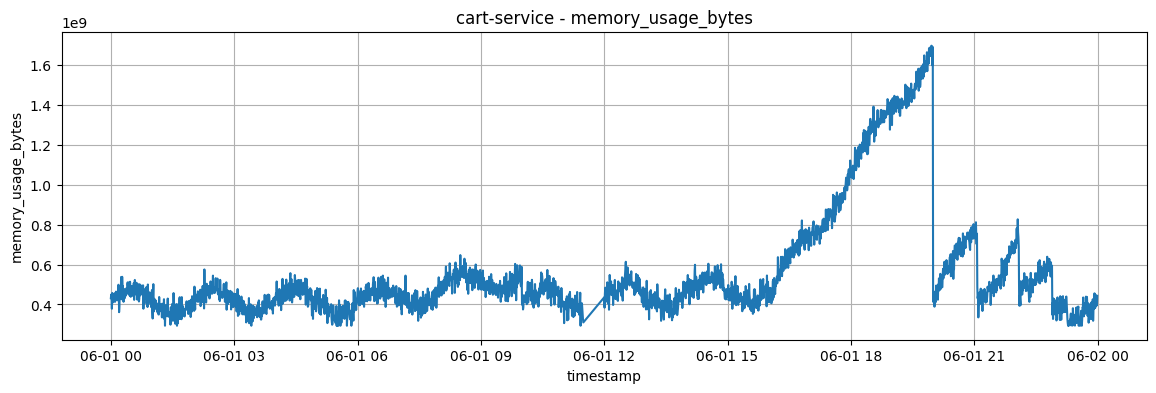

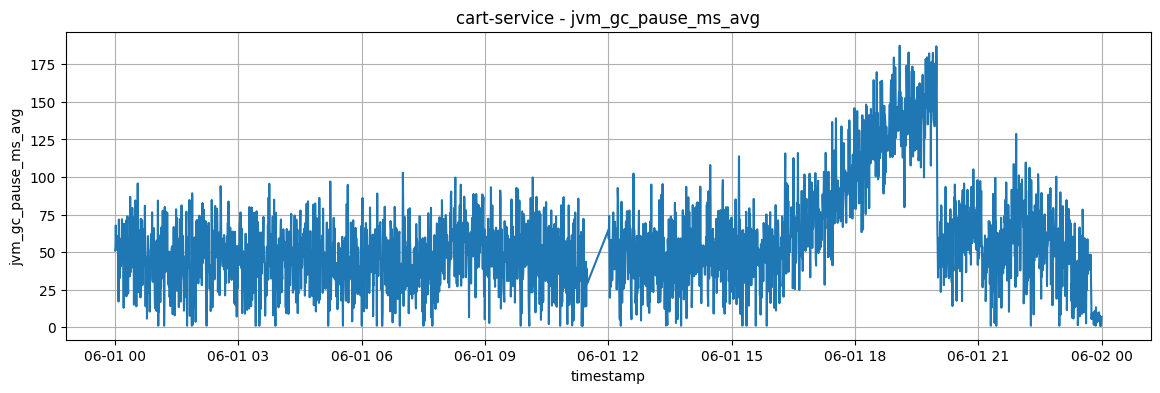

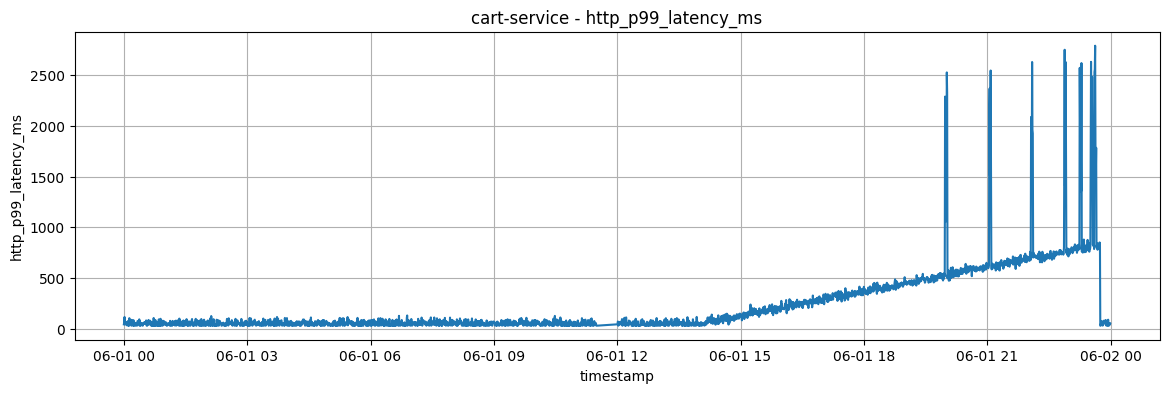

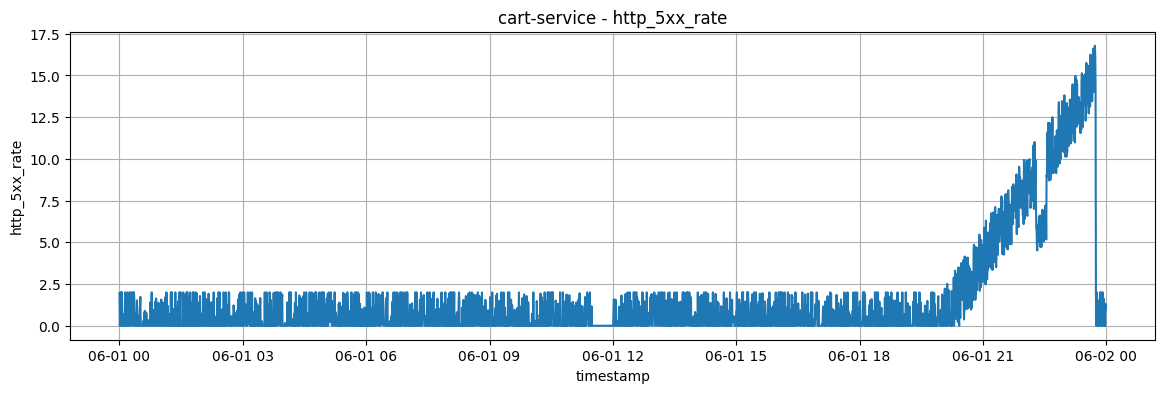

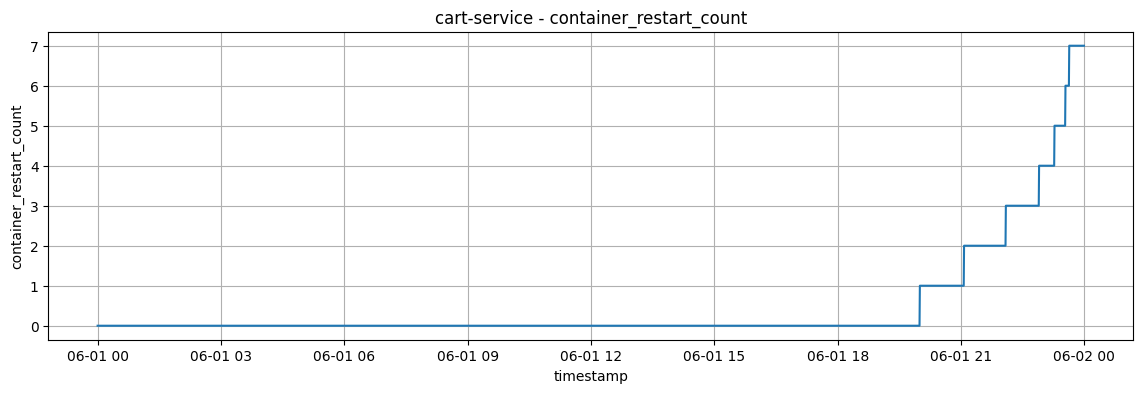

In [19]:
import matplotlib.pyplot as plt

cart_plot = cart.copy()
metrics_to_plot = [
    "memory_usage_bytes",
    "jvm_gc_pause_ms_avg",
    "http_p99_latency_ms",
    "http_5xx_rate",
    "container_restart_count"
]

for col in metrics_to_plot:
    plt.figure(figsize=(14, 4))
    plt.plot(cart_plot["timestamp"], cart_plot[col])
    plt.title(f"cart-service - {col}")
    plt.xlabel("timestamp")
    plt.ylabel(col)
    plt.grid(True)
    plt.show()


In [20]:
cart[cart["http_5xx_rate"] > 5][["timestamp", "http_5xx_rate"]].head()
cart[cart["container_restart_count"] > 0][
    ["timestamp", "container_restart_count"]
].head()

,timestamp,container_restart_count
2340,2026-06-01 20:00:00+00:00,1
2341,2026-06-01 20:00:30+00:00,1
2342,2026-06-01 20:01:00+00:00,1
2343,2026-06-01 20:01:30+00:00,1
2344,2026-06-01 20:02:00+00:00,1


In [21]:
cart[cart["container_restart_count"] > 0][
    ["timestamp", "container_restart_count"]
].head()

,timestamp,container_restart_count
2340,2026-06-01 20:00:00+00:00,1
2341,2026-06-01 20:00:30+00:00,1
2342,2026-06-01 20:01:00+00:00,1
2343,2026-06-01 20:01:30+00:00,1
2344,2026-06-01 20:02:00+00:00,1


In [22]:
cart["memory_usage_percent"] = cart["memory_usage_bytes"] / cart["memory_limit_bytes"] * 100

cart[cart["memory_usage_percent"] > 80][
    ["timestamp", "memory_usage_percent", "memory_usage_bytes", "memory_limit_bytes"]
].head()

,timestamp,memory_usage_percent,memory_usage_bytes,memory_limit_bytes


In [23]:
cart[cart["http_5xx_rate"] > 5][
    ["timestamp", "http_5xx_rate"]
].head(10)


,timestamp,http_5xx_rate
2450,2026-06-01 20:55:00+00:00,5.46
2452,2026-06-01 20:56:00+00:00,5.08
2455,2026-06-01 20:57:30+00:00,5.14
2464,2026-06-01 21:02:00+00:00,5.88
2466,2026-06-01 21:03:00+00:00,5.65
2469,2026-06-01 21:04:30+00:00,6.29
2474,2026-06-01 21:07:00+00:00,5.54
2476,2026-06-01 21:08:00+00:00,5.59
2481,2026-06-01 21:10:30+00:00,6.13
2484,2026-06-01 21:12:00+00:00,6.74


In [24]:
cart[cart["http_p99_latency_ms"] > 500][
    ["timestamp", "http_p99_latency_ms"]
].head(10)

,timestamp,http_p99_latency_ms
2219,2026-06-01 18:59:30+00:00,508.0
2254,2026-06-01 19:17:00+00:00,528.1
2258,2026-06-01 19:19:00+00:00,501.1
2269,2026-06-01 19:24:30+00:00,507.1
2271,2026-06-01 19:25:30+00:00,505.7
2272,2026-06-01 19:26:00+00:00,541.2
2283,2026-06-01 19:31:30+00:00,506.6
2284,2026-06-01 19:32:00+00:00,505.5
2285,2026-06-01 19:32:30+00:00,510.3
2296,2026-06-01 19:38:00+00:00,506.8


In [25]:
cart[cart["jvm_gc_pause_ms_avg"] > 200][
    ["timestamp", "jvm_gc_pause_ms_avg"]
].head(10)

,timestamp,jvm_gc_pause_ms_avg


In [26]:
cart[[
    "memory_usage_percent",
    "http_p99_latency_ms",
    "http_5xx_rate",
    "jvm_gc_pause_ms_avg",
    "container_restart_count"
]].describe()

,memory_usage_percent,http_p99_latency_ms,http_5xx_rate,jvm_gc_pause_ms_avg,container_restart_count
count,2820.000000,2820.000000,2820.000000,2820.000000,2820.000000
mean,26.178756,232.422128,1.605933,56.988723,0.488652
std,12.999760,323.684020,3.067855,32.919320,1.316880
min,13.671875,30.000000,0.000000,1.000000,0.000000
25%,19.266203,44.900000,0.000000,36.300000,0.000000
50%,21.948000,74.000000,0.380000,52.100000,0.000000
75%,25.771732,356.250000,1.652500,70.425000,0.000000
max,79.038742,2789.800000,16.780000,187.400000,7.000000


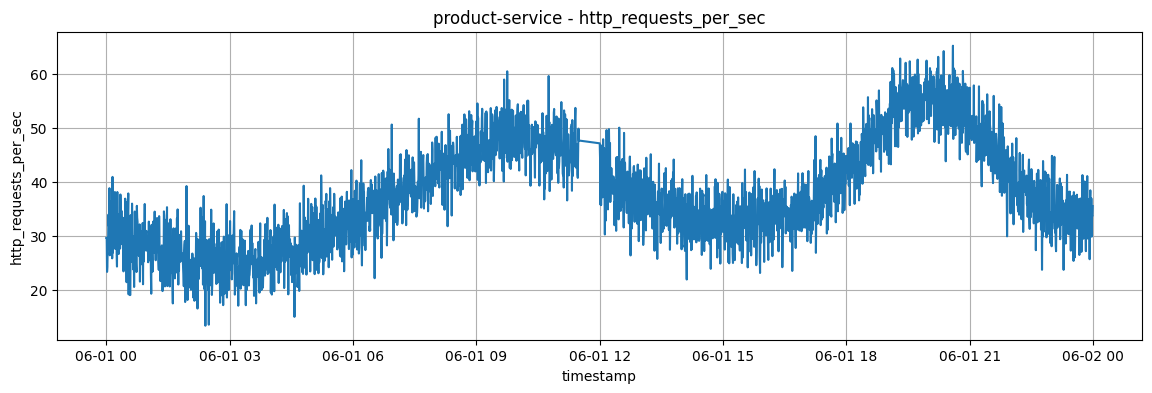

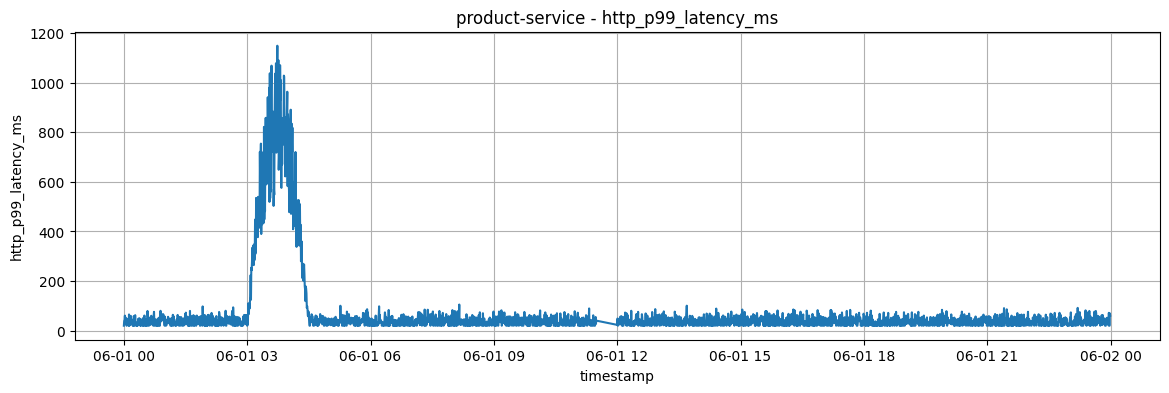

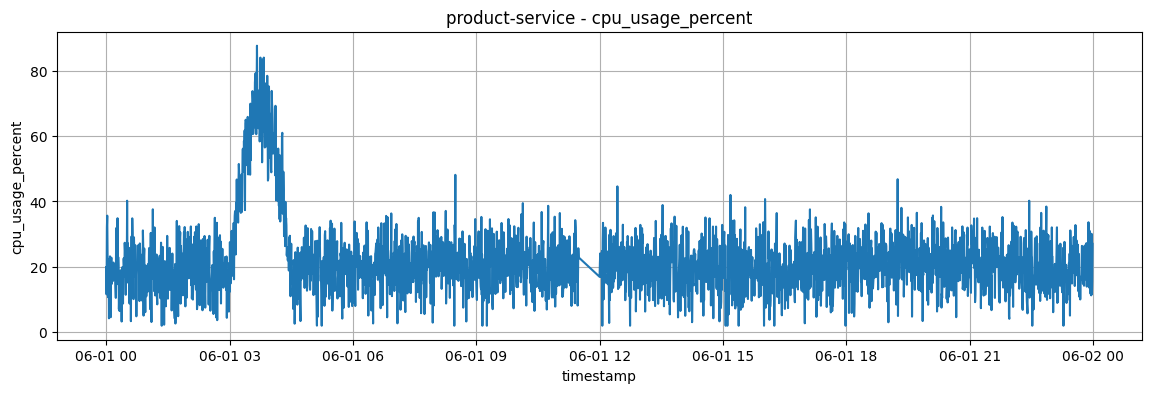

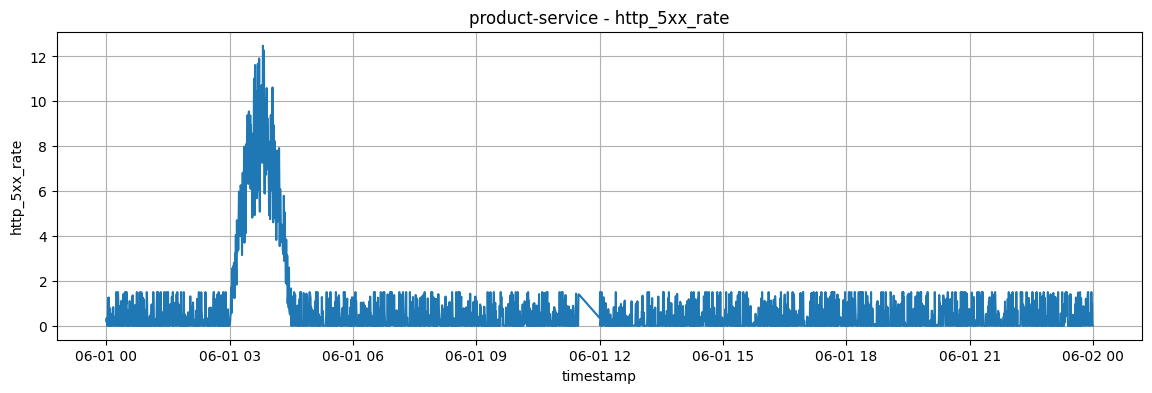

In [12]:
product = pd.read_csv(METRICS_DIR / "product-service.csv", parse_dates=["timestamp"])
product[[
    "http_requests_per_sec",
    "http_p99_latency_ms",
    "cpu_usage_percent",
    "http_5xx_rate"
]].describe()
metrics_to_plot = [
    "http_requests_per_sec",
    "http_p99_latency_ms",
    "cpu_usage_percent",
    "http_5xx_rate"
]

for col in metrics_to_plot:
    plt.figure(figsize=(14, 4))
    plt.plot(product["timestamp"], product[col])
    plt.title(f"product-service - {col}")
    plt.xlabel("timestamp")
    plt.ylabel(col)
    plt.grid(True)
    plt.show()

##  Cart-Service Metric Timeline

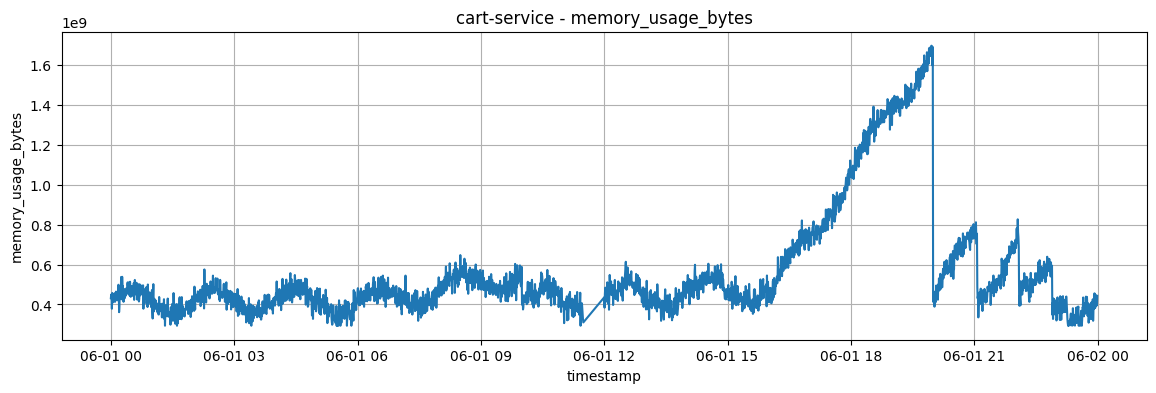

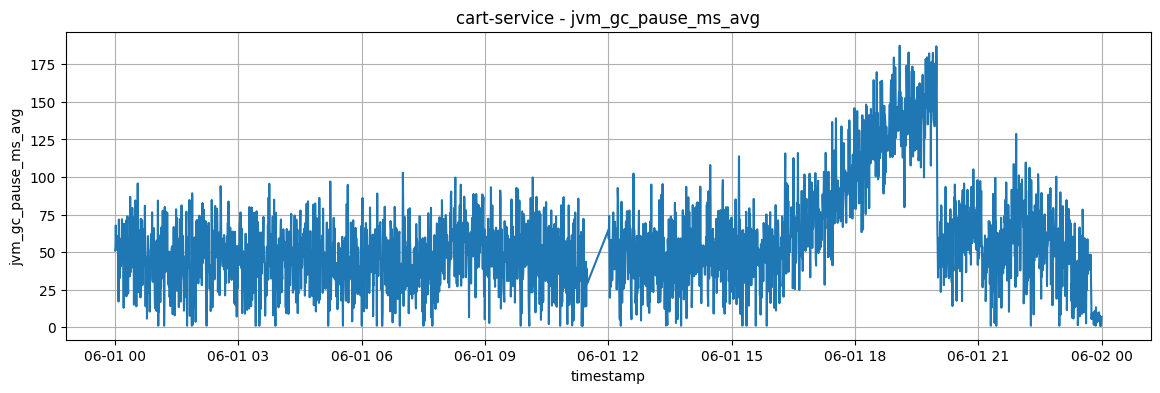

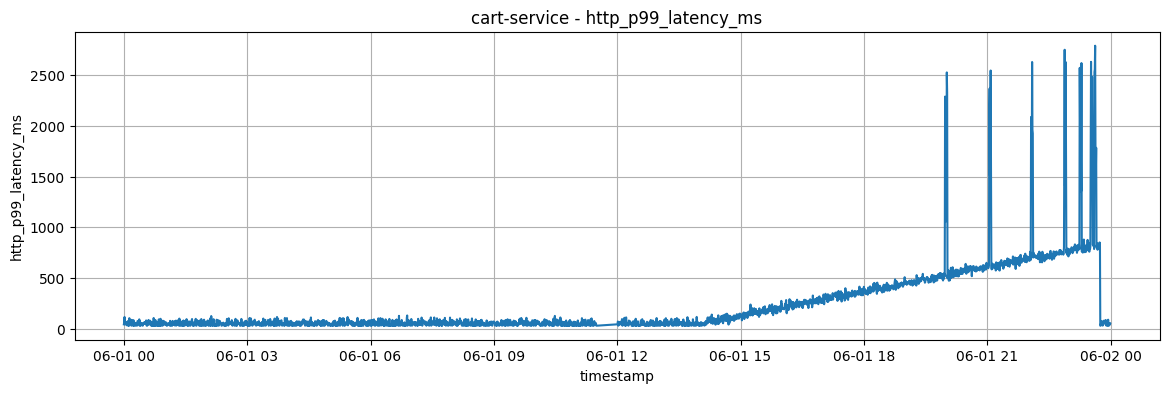

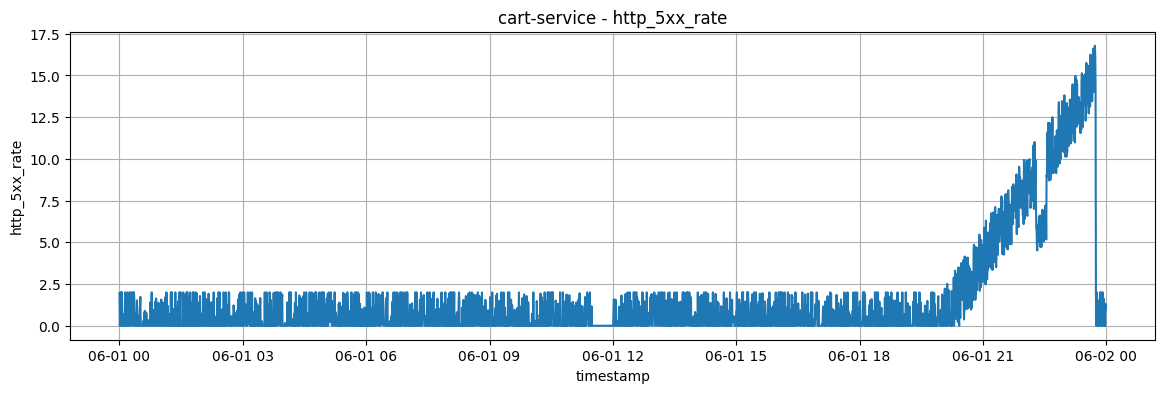

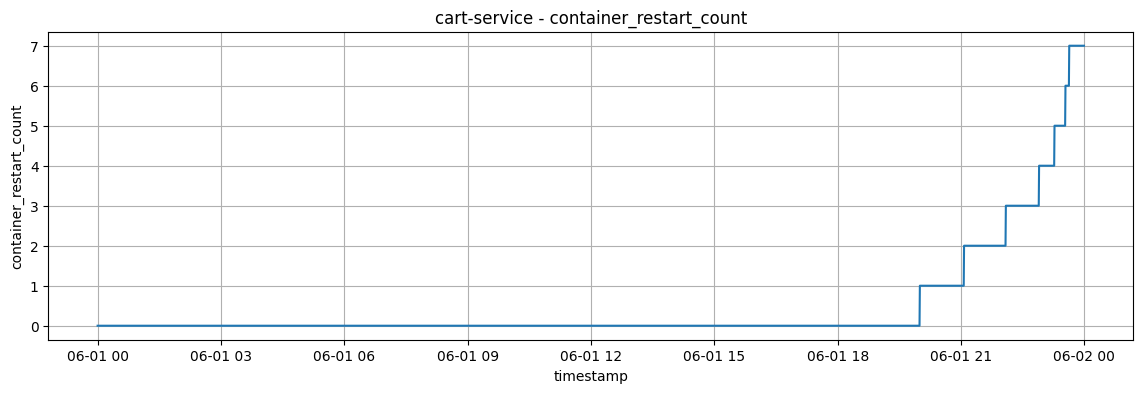

In [11]:
import matplotlib.pyplot as plt

metrics_to_plot = [
    "memory_usage_bytes",
    "jvm_gc_pause_ms_avg",
    "http_p99_latency_ms",
    "http_5xx_rate",
    "container_restart_count"
]

for col in metrics_to_plot:
    plt.figure(figsize=(14, 4))
    plt.plot(cart["timestamp"], cart[col])
    plt.title(f"cart-service - {col}")
    plt.xlabel("timestamp")
    plt.ylabel(col)
    plt.grid(True)
    plt.show()

In [28]:
cart[cart["http_p99_latency_ms"] > 500][
    ["timestamp", "http_p99_latency_ms"]
].head(10)

,timestamp,http_p99_latency_ms
2219,2026-06-01 18:59:30+00:00,508.0
2254,2026-06-01 19:17:00+00:00,528.1
2258,2026-06-01 19:19:00+00:00,501.1
2269,2026-06-01 19:24:30+00:00,507.1
2271,2026-06-01 19:25:30+00:00,505.7
2272,2026-06-01 19:26:00+00:00,541.2
2283,2026-06-01 19:31:30+00:00,506.6
2284,2026-06-01 19:32:00+00:00,505.5
2285,2026-06-01 19:32:30+00:00,510.3
2296,2026-06-01 19:38:00+00:00,506.8


In [29]:
cart[cart["container_restart_count"] > 0][
    ["timestamp", "container_restart_count"]
].head(10)

,timestamp,container_restart_count
2340,2026-06-01 20:00:00+00:00,1
2341,2026-06-01 20:00:30+00:00,1
2342,2026-06-01 20:01:00+00:00,1
2343,2026-06-01 20:01:30+00:00,1
2344,2026-06-01 20:02:00+00:00,1
2345,2026-06-01 20:02:30+00:00,1
2346,2026-06-01 20:03:00+00:00,1
2347,2026-06-01 20:03:30+00:00,1
2348,2026-06-01 20:04:00+00:00,1
2349,2026-06-01 20:04:30+00:00,1


In [30]:
cart[cart["http_5xx_rate"] > 5][
    ["timestamp", "http_5xx_rate"]
].head(10)

,timestamp,http_5xx_rate
2450,2026-06-01 20:55:00+00:00,5.46
2452,2026-06-01 20:56:00+00:00,5.08
2455,2026-06-01 20:57:30+00:00,5.14
2464,2026-06-01 21:02:00+00:00,5.88
2466,2026-06-01 21:03:00+00:00,5.65
2469,2026-06-01 21:04:30+00:00,6.29
2474,2026-06-01 21:07:00+00:00,5.54
2476,2026-06-01 21:08:00+00:00,5.59
2481,2026-06-01 21:10:30+00:00,6.13
2484,2026-06-01 21:12:00+00:00,6.74


In [31]:
order[order["upstream_timeout_rate"] > 5][
    ["timestamp", "upstream_timeout_rate"]
].head(10)
payment[payment["upstream_timeout_rate"] > 5][
    ["timestamp", "upstream_timeout_rate"]
].head(10)
api[api["cart_upstream_error_rate"] > 5][
    ["timestamp", "cart_upstream_error_rate"]
].head(10)
print("order max timeout:", order["upstream_timeout_rate"].max())
print("payment max timeout:", payment["upstream_timeout_rate"].max())
print("api max cart upstream error:", api["cart_upstream_error_rate"].max())

order max timeout: 27.05
payment max timeout: 15.82
api max cart upstream error: 20.12


In [32]:
order[order["upstream_timeout_rate"] > 5][
    ["timestamp", "upstream_timeout_rate"]
].head(10)


,timestamp,upstream_timeout_rate
2450,2026-06-01 20:55:00+00:00,5.22
2461,2026-06-01 21:00:30+00:00,5.58
2464,2026-06-01 21:02:00+00:00,5.97
2467,2026-06-01 21:03:30+00:00,5.39
2468,2026-06-01 21:04:00+00:00,6.05
2470,2026-06-01 21:05:00+00:00,5.82
2473,2026-06-01 21:06:30+00:00,6.02
2475,2026-06-01 21:07:30+00:00,5.10
2476,2026-06-01 21:08:00+00:00,6.85
2477,2026-06-01 21:08:30+00:00,5.14


In [33]:
payment[payment["upstream_timeout_rate"] > 5][
    ["timestamp", "upstream_timeout_rate"]
].head(10)

,timestamp,upstream_timeout_rate
2516,2026-06-01 21:28:00+00:00,5.26
2519,2026-06-01 21:29:30+00:00,5.58
2521,2026-06-01 21:30:30+00:00,5.18
2525,2026-06-01 21:32:30+00:00,5.74
2526,2026-06-01 21:33:00+00:00,5.81
2527,2026-06-01 21:33:30+00:00,5.13
2532,2026-06-01 21:36:00+00:00,5.10
2533,2026-06-01 21:36:30+00:00,5.81
2538,2026-06-01 21:39:00+00:00,5.93
2543,2026-06-01 21:41:30+00:00,5.87


In [34]:
api[api["cart_upstream_error_rate"] > 5][
    ["timestamp", "cart_upstream_error_rate"]
].head(10)

,timestamp,cart_upstream_error_rate
2432,2026-06-01 20:46:00+00:00,5.05
2439,2026-06-01 20:49:30+00:00,5.94
2446,2026-06-01 20:53:00+00:00,6.13
2449,2026-06-01 20:54:30+00:00,5.56
2451,2026-06-01 20:55:30+00:00,5.03
2455,2026-06-01 20:57:30+00:00,5.07
2458,2026-06-01 20:59:00+00:00,6.45
2459,2026-06-01 20:59:30+00:00,6.45
2461,2026-06-01 21:00:30+00:00,6.60
2462,2026-06-01 21:01:00+00:00,5.26


## Metric Timeline Findings

Cart-service degradation started before the official alert.

Observed metric timeline:
- 2026-06-01 18:59:30 UTC: cart-service p99 latency first exceeded 500ms.
- 2026-06-01 20:00:00 UTC: cart-service container restart count first increased.
- 2026-06-01 20:46:00 UTC: api-gateway cart_upstream_error_rate first exceeded 5%.
- 2026-06-01 20:55:00 UTC: cart-service HTTP 5xx rate first exceeded 5%.
- 2026-06-01 20:55:00 UTC: order-service upstream_timeout_rate first exceeded 5%.
- 2026-06-01 21:28:00 UTC: payment-service upstream_timeout_rate first exceeded 5%.
- 2026-06-01 23:04:00 UTC: official alert time from the assignment.

The earliest clear metric signal is cart-service p99 latency at 2026-06-01 18:59:30 UTC. This is about 4 hours before the official alert. The downstream impact appears later, first at api-gateway and order-service, then payment-service.

## Anomaly Detection

In [35]:
import numpy as np

def rolling_zscore_anomaly(df, col, window=120, threshold=3):
    """
    window=120 means 120 samples.
    Since each sample is 30 seconds, 120 samples = 60 minutes.
    """
    rolling_mean = df[col].rolling(window=window, min_periods=window//2).mean()
    rolling_std = df[col].rolling(window=window, min_periods=window//2).std()

    zscore = (df[col] - rolling_mean) / rolling_std

    return zscore, zscore.abs() > threshold
cart_signals = [
    "http_p99_latency_ms",
    "http_5xx_rate",
    "jvm_gc_pause_ms_avg",
    "container_restart_count"
]

for col in cart_signals:
    z_col = f"{col}_zscore"
    anomaly_col = f"{col}_z_anomaly"

    cart[z_col], cart[anomaly_col] = rolling_zscore_anomaly(
        cart,
        col,
        window=120,
        threshold=3
    )

    first_anomaly = cart[cart[anomaly_col]][["timestamp", col, z_col]].head(1)

    print("\n", col)
    print(first_anomaly)


 http_p99_latency_ms
                    timestamp  http_p99_latency_ms  http_p99_latency_ms_zscore
255 2026-06-01 02:07:30+00:00                125.2                    3.235689

 http_5xx_rate
                     timestamp  http_5xx_rate  http_5xx_rate_zscore
2375 2026-06-01 20:17:30+00:00           2.89               3.10553

 jvm_gc_pause_ms_avg
                     timestamp  jvm_gc_pause_ms_avg  \
1896 2026-06-01 16:18:00+00:00                115.7   

      jvm_gc_pause_ms_avg_zscore  
1896                    3.533981  

 container_restart_count
                     timestamp  container_restart_count  \
2340 2026-06-01 20:00:00+00:00                        1   

      container_restart_count_zscore  
2340                       10.863164  


In [36]:
def mad_anomaly(df, col, threshold=3.5):
    """
    MAD = Median Absolute Deviation.
    More robust than mean/std when data has spikes.
    """
    median = df[col].median()
    mad = np.median(np.abs(df[col] - median))

    if mad == 0:
        modified_z = pd.Series(np.zeros(len(df)), index=df.index)
    else:
        modified_z = 0.6745 * (df[col] - median) / mad

    return modified_z, modified_z.abs() > threshold
for col in cart_signals:
    mad_col = f"{col}_mad_score"
    anomaly_col = f"{col}_mad_anomaly"

    cart[mad_col], cart[anomaly_col] = mad_anomaly(
        cart,
        col,
        threshold=3.5
    )

    first_anomaly = cart[cart[anomaly_col]][["timestamp", col, mad_col]].head(1)

    print("\n", col)
    print(first_anomaly)


 http_p99_latency_ms
                     timestamp  http_p99_latency_ms  \
1951 2026-06-01 16:45:30+00:00                327.7   

      http_p99_latency_ms_mad_score  
1951                        3.89353  

 http_5xx_rate
                     timestamp  http_5xx_rate  http_5xx_rate_mad_score
2356 2026-06-01 20:08:00+00:00           2.51                  3.78075

 jvm_gc_pause_ms_avg
                     timestamp  jvm_gc_pause_ms_avg  \
2098 2026-06-01 17:59:00+00:00                145.8   

      jvm_gc_pause_ms_avg_mad_score  
2098                       3.728652  

 container_restart_count
Empty DataFrame
Columns: [timestamp, container_restart_count, container_restart_count_mad_score]
Index: []


In [37]:
comparison_rows = []

for col in cart_signals:
    z_anomaly_col = f"{col}_z_anomaly"
    mad_anomaly_col = f"{col}_mad_anomaly"

    z_first = cart.loc[cart[z_anomaly_col], "timestamp"].min()
    mad_first = cart.loc[cart[mad_anomaly_col], "timestamp"].min()

    comparison_rows.append({
        "metric": col,
        "rolling_zscore_first_anomaly": z_first,
        "mad_first_anomaly": mad_first,
        "rolling_zscore_count": int(cart[z_anomaly_col].sum()),
        "mad_count": int(cart[mad_anomaly_col].sum())
    })

comparison = pd.DataFrame(comparison_rows)
comparison

,metric,rolling_zscore_first_anomaly,mad_first_anomaly,rolling_zscore_count,mad_count
0,http_p99_latency_ms,2026-06-01 02:07:30+00:00,2026-06-01 16:45:30+00:00,40,791
1,http_5xx_rate,2026-06-01 20:17:30+00:00,2026-06-01 20:08:00+00:00,13,381
2,jvm_gc_pause_ms_avg,2026-06-01 16:18:00+00:00,2026-06-01 17:59:00+00:00,14,101
3,container_restart_count,2026-06-01 20:00:00+00:00,NaT,35,0


In [38]:
comparison.to_csv("../outputs/cart_anomaly_detection_comparison.csv", index=False)

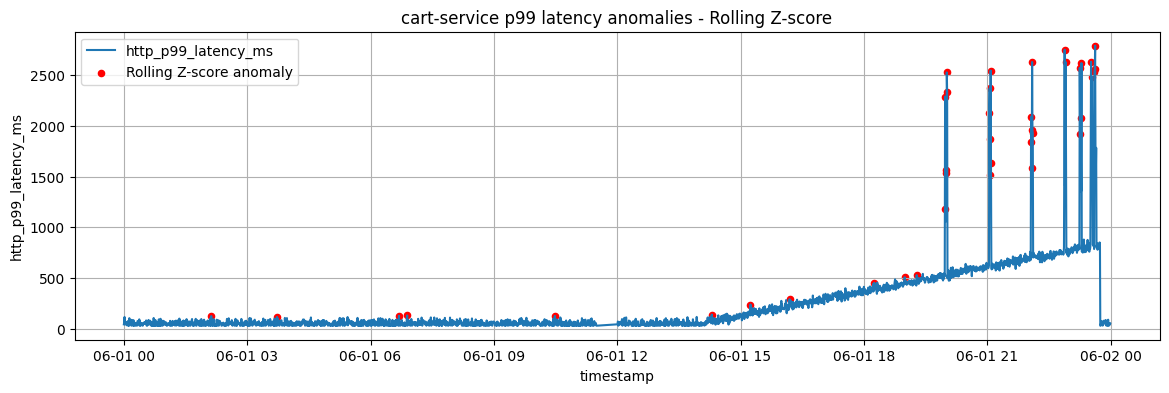

In [39]:
col = "http_p99_latency_ms"

plt.figure(figsize=(14, 4))
plt.plot(cart["timestamp"], cart[col], label=col)

anomalies = cart[cart[f"{col}_z_anomaly"]]
plt.scatter(
    anomalies["timestamp"],
    anomalies[col],
    color="red",
    s=20,
    label="Rolling Z-score anomaly"
)

plt.title("cart-service p99 latency anomalies - Rolling Z-score")
plt.xlabel("timestamp")
plt.ylabel(col)
plt.legend()
plt.grid(True)
plt.show()

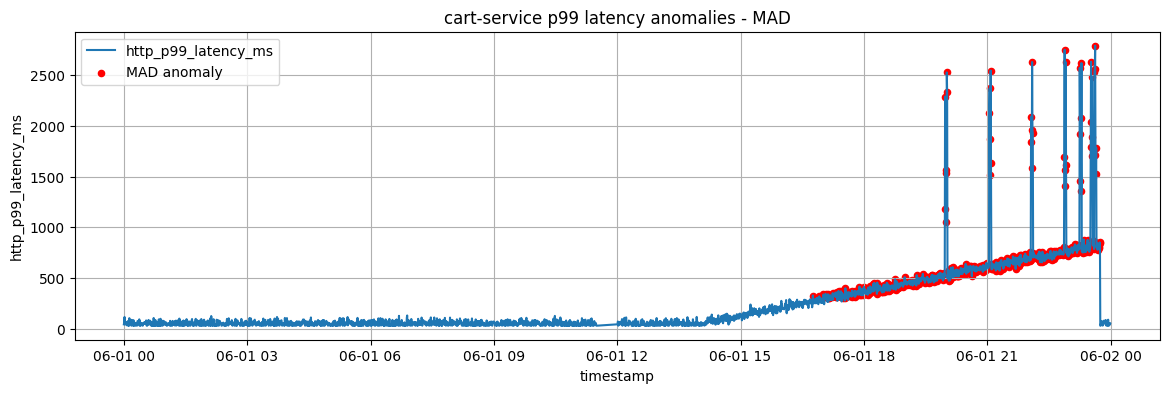

In [40]:
col = "http_p99_latency_ms"

plt.figure(figsize=(14, 4))
plt.plot(cart["timestamp"], cart[col], label=col)

anomalies = cart[cart[f"{col}_mad_anomaly"]]
plt.scatter(
    anomalies["timestamp"],
    anomalies[col],
    color="red",
    s=20,
    label="MAD anomaly"
)

plt.title("cart-service p99 latency anomalies - MAD")
plt.xlabel("timestamp")
plt.ylabel(col)
plt.legend()
plt.grid(True)
plt.show()

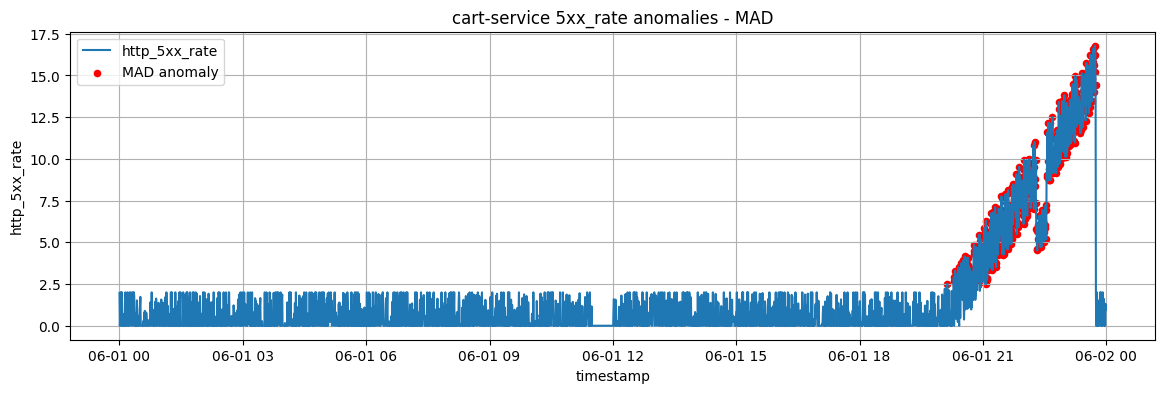

In [41]:
col = "http_5xx_rate"

plt.figure(figsize=(14, 4))
plt.plot(cart["timestamp"], cart[col], label=col)

anomalies = cart[cart[f"{col}_mad_anomaly"]]
plt.scatter(
    anomalies["timestamp"],
    anomalies[col],
    color="red",
    s=20,
    label="MAD anomaly"
)

plt.title("cart-service 5xx_rate anomalies - MAD")
plt.xlabel("timestamp")
plt.ylabel(col)
plt.legend()
plt.grid(True)
plt.show()

In [42]:
comparison

,metric,rolling_zscore_first_anomaly,mad_first_anomaly,rolling_zscore_count,mad_count
0,http_p99_latency_ms,2026-06-01 02:07:30+00:00,2026-06-01 16:45:30+00:00,40,791
1,http_5xx_rate,2026-06-01 20:17:30+00:00,2026-06-01 20:08:00+00:00,13,381
2,jvm_gc_pause_ms_avg,2026-06-01 16:18:00+00:00,2026-06-01 17:59:00+00:00,14,101
3,container_restart_count,2026-06-01 20:00:00+00:00,NaT,35,0


## Log Analysis

In [43]:
cart_logs = pd.read_json(LOGS_DIR / "cart-service.log.jsonl", lines=True)
order_logs = pd.read_json(LOGS_DIR / "order-service.log.jsonl", lines=True)

cart_logs["timestamp"] = pd.to_datetime(cart_logs["timestamp"], utc=True)
order_logs["timestamp"] = pd.to_datetime(order_logs["timestamp"], utc=True)

print("cart logs:", cart_logs.shape)
print("order logs:", order_logs.shape)

cart_logs.head()

cart logs: (24292, 11)
order logs: (8020, 7)


,timestamp,level,service,pod,trace_id,message,duration_ms,cache_size_mb,heap_used_mb,retry_count,memory_limit_bytes
0,2026-06-01 00:00:18.233000+00:00,INFO,cart-service,cart-service-7d9f8b-xaji0,93cfe89bbb8a00ff,Item added to cart for userId=25845,17.0,NaN,NaN,NaN,NaN
1,2026-06-01 00:00:18.651000+00:00,INFO,cart-service,cart-service-7d9f8b-xaji0,e0dfffbaec7eaee9,Item added to cart for userId=68915,5.0,NaN,NaN,NaN,NaN
2,2026-06-01 00:00:19.437000+00:00,INFO,cart-service,cart-service-7d9f8b-thv3a,b2b4ea8ce9b90bb7,Health check passed,3.0,NaN,NaN,NaN,NaN
3,2026-06-01 00:00:19.656000+00:00,INFO,cart-service,cart-service-7d9f8b-xaji0,635eee6fa267b55a,DB query executed table=cart rows=43,14.0,NaN,NaN,NaN,NaN
4,2026-06-01 00:00:32.774000+00:00,INFO,cart-service,cart-service-7d9f8b-y6dpb,8f322ce1cce86b2d,Item added to cart for userId=45128,7.0,NaN,NaN,NaN,NaN


In [44]:
print(cart_logs.columns.tolist())
print(order_logs.columns.tolist())

['timestamp', 'level', 'service', 'pod', 'trace_id', 'message', 'duration_ms', 'cache_size_mb', 'heap_used_mb', 'retry_count', 'memory_limit_bytes']
['timestamp', 'level', 'service', 'pod', 'trace_id', 'message', 'duration_ms']


In [45]:
cart_logs["level"].value_counts()

level
INFO     13182
WARN      8830
ERROR     1457
FATAL      823
Name: count, dtype: int64

In [46]:
order_logs["level"].value_counts()

level
INFO     6474
WARN     1080
ERROR     466
Name: count, dtype: int64

In [47]:
cart_logs["bucket_5m"] = cart_logs["timestamp"].dt.floor("5min")
order_logs["bucket_5m"] = order_logs["timestamp"].dt.floor("5min")
cart_level_5m = (
    cart_logs
    .groupby(["bucket_5m", "level"])
    .size()
    .reset_index(name="count")
)

cart_level_5m.head()

,bucket_5m,level,count
0,2026-06-01 00:00:00+00:00,INFO,52
1,2026-06-01 00:00:00+00:00,WARN,5
2,2026-06-01 00:05:00+00:00,INFO,58
3,2026-06-01 00:05:00+00:00,WARN,3
4,2026-06-01 00:10:00+00:00,INFO,44


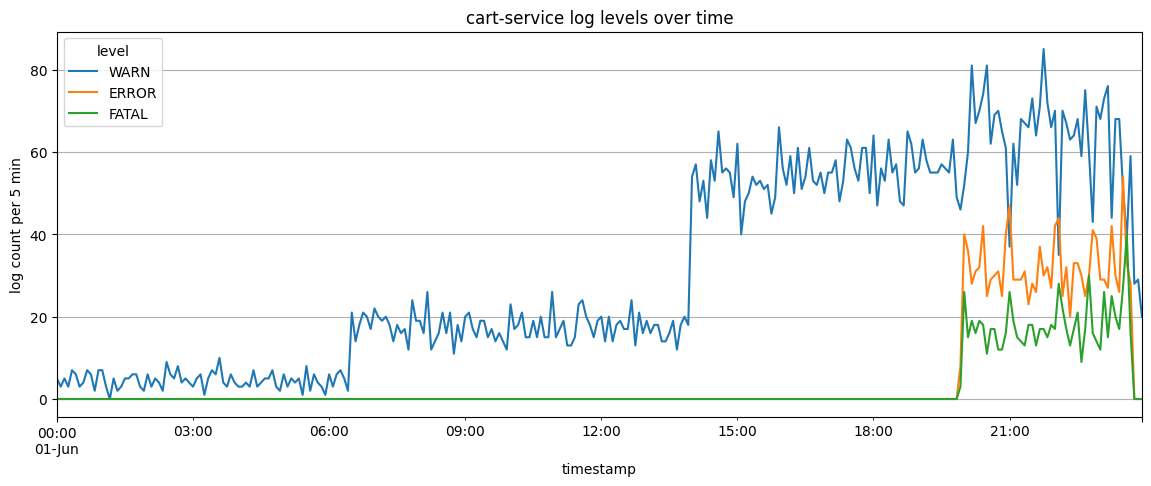

In [48]:
cart_level_pivot = (
    cart_level_5m
    .pivot(index="bucket_5m", columns="level", values="count")
    .fillna(0)
)

cart_level_pivot[["WARN", "ERROR", "FATAL"]].plot(figsize=(14, 5))
plt.title("cart-service log levels over time")
plt.xlabel("timestamp")
plt.ylabel("log count per 5 min")
plt.grid(True)
plt.show()

In [49]:
cart_logs[cart_logs["level"].isin(["WARN", "ERROR", "FATAL"])][
    ["timestamp", "level", "pod", "message"]
].head(20)

,timestamp,level,pod,message
10,2026-06-01 00:01:20.030000+00:00,WARN,cart-service-7d9f8b-hsahx,Health check response time elevated endpoint=/...
20,2026-06-01 00:02:16.689000+00:00,WARN,cart-service-7d9f8b-thv3a,Cache warm-up slower than expected startup_ms=...
48,2026-06-01 00:04:22.990000+00:00,WARN,cart-service-7d9f8b-thv3a,Cache warm-up slower than expected startup_ms=...
50,2026-06-01 00:04:35.358000+00:00,WARN,cart-service-7d9f8b-y6dpb,Health check response time elevated endpoint=/...
53,2026-06-01 00:04:45.868000+00:00,WARN,cart-service-7d9f8b-hsahx,Connection pool nearing limit pool=db connecti...
87,2026-06-01 00:07:52.646000+00:00,WARN,cart-service-7d9f8b-hsahx,Cache warm-up slower than expected startup_ms=...
88,2026-06-01 00:07:56.056000+00:00,WARN,cart-service-7d9f8b-xaji0,Cache warm-up slower than expected startup_ms=...
99,2026-06-01 00:08:44.817000+00:00,WARN,cart-service-7d9f8b-y6dpb,Connection pool nearing limit pool=db connecti...
121,2026-06-01 00:10:30.125000+00:00,WARN,cart-service-7d9f8b-xaji0,Connection pool nearing limit pool=db connecti...
128,2026-06-01 00:11:21.968000+00:00,WARN,cart-service-7d9f8b-hsahx,Connection pool nearing limit pool=db connecti...


In [50]:
for level in ["WARN", "ERROR", "FATAL"]:
    subset = cart_logs[cart_logs["level"] == level]
    print(level, subset["timestamp"].min(), len(subset))

WARN 2026-06-01 00:01:20.030000+00:00 8830
ERROR 2026-06-01 19:59:15.939000+00:00 1457
FATAL 2026-06-01 19:59:31.047000+00:00 823


In [51]:
cart_logs["message"].value_counts().head(30)

message
Health check passed                                            3186
ProductCatalogCache eviction failed: heap pressure too high    2671
OutOfMemoryError imminent: available heap < 5%                  936
Container OOMKilled: memory limit exceeded                      823
Upstream connection refused host=product-service                521
Connection pool nearing limit pool=db connections=49/50         116
Connection pool nearing limit pool=db connections=43/50         109
Connection pool nearing limit pool=db connections=48/50         107
Connection pool nearing limit pool=db connections=45/50         106
Connection pool nearing limit pool=db connections=44/50         105
Connection pool nearing limit pool=db connections=40/50         104
Application starting up version=2.4.1                           104
Connection pool nearing limit pool=db connections=50/50          96
Connection pool nearing limit pool=db connections=41/50          93
Connection pool nearing limit pool=db co

In [52]:
import re

def normalize_message(msg):
    msg = str(msg)
    msg = re.sub(r"userId=\d+", "userId=<id>", msg)
    msg = re.sub(r"cartId=\d+", "cartId=<id>", msg)
    msg = re.sub(r"orderId=\d+", "orderId=<id>", msg)
    msg = re.sub(r"productId=\d+", "productId=<id>", msg)
    msg = re.sub(r"\b\d+\b", "<num>", msg)
    msg = re.sub(r"[a-f0-9]{8,}", "<hex>", msg)
    return msg

cart_logs["message_pattern"] = cart_logs["message"].apply(normalize_message)
order_logs["message_pattern"] = order_logs["message"].apply(normalize_message)

In [53]:
cart_logs["message_pattern"].value_counts().head(30)

message_pattern
Health check passed                                                   3186
Item added to cart for userId=<id>                                    3158
DB query executed table=cart rows=<num>                               2822
ProductCatalogCache eviction failed: heap pressure too high           2671
Checkout completed orderId=ORD-<num>                                  2041
ProductCatalogCache loaded <num> entries                              1871
Connection pool nearing limit pool=db connections=<num>/<num>         1104
OutOfMemoryError imminent: available heap < <num>%                     936
Container OOMKilled: memory limit exceeded                             823
Cache warm-up slower than expected startup_ms=<num>                    734
Upstream connection refused host=product-service                       521
Application starting up version=<num>.<num>.<num>                      104
Health check response time elevated endpoint=/health latency=231ms      11
GC overhe

In [54]:
cart_logs[cart_logs["level"].isin(["WARN", "ERROR", "FATAL"])]["message_pattern"].value_counts().head(30)

message_pattern
ProductCatalogCache eviction failed: heap pressure too high           2671
Connection pool nearing limit pool=db connections=<num>/<num>         1104
OutOfMemoryError imminent: available heap < <num>%                     936
Container OOMKilled: memory limit exceeded                             823
Cache warm-up slower than expected startup_ms=<num>                    734
Upstream connection refused host=product-service                       521
Health check response time elevated endpoint=/health latency=231ms      11
GC overhead limit warning: pause=778ms heap=<num>%                      11
Health check response time elevated endpoint=/health latency=209ms      11
GC overhead limit warning: pause=329ms heap=<num>%                      11
Health check response time elevated endpoint=/health latency=139ms      10
Health check response time elevated endpoint=/health latency=212ms      10
Health check response time elevated endpoint=/health latency=226ms      10
Health ch

In [55]:
cart_pattern_summary = (
    cart_logs
    .groupby(["level", "message_pattern"])
    .agg(
        first_seen=("timestamp", "min"),
        last_seen=("timestamp", "max"),
        count=("message_pattern", "size")
    )
    .reset_index()
    .sort_values(["first_seen", "count"], ascending=[True, False])
)

cart_pattern_summary.head(30)

,level,message_pattern,first_seen,last_seen,count
7,INFO,Item added to cart for userId=<id>,2026-06-01 00:00:18.233000+00:00,2026-06-01 23:58:55.577000+00:00,3158
6,INFO,Health check passed,2026-06-01 00:00:19.437000+00:00,2026-06-01 23:59:44.589000+00:00,3186
5,INFO,DB query executed table=cart rows=<num>,2026-06-01 00:00:19.656000+00:00,2026-06-01 23:59:33.621000+00:00,2822
618,WARN,Health check response time elevated endpoint=/...,2026-06-01 00:01:20.030000+00:00,2026-06-01 23:26:38.819000+00:00,7
4,INFO,Checkout completed orderId=ORD-<num>,2026-06-01 00:02:10.733000+00:00,2026-06-01 23:57:40.362000+00:00,2041
8,INFO,ProductCatalogCache loaded <num> entries,2026-06-01 00:02:10.942000+00:00,2026-06-01 23:59:10.512000+00:00,1871
9,WARN,Cache warm-up slower than expected startup_ms=...,2026-06-01 00:02:16.689000+00:00,2026-06-01 23:56:17.886000+00:00,734
716,WARN,Health check response time elevated endpoint=/...,2026-06-01 00:04:35.358000+00:00,2026-06-01 19:06:35.138000+00:00,5
10,WARN,Connection pool nearing limit pool=db connecti...,2026-06-01 00:04:45.868000+00:00,2026-06-01 23:57:09.726000+00:00,1104
635,WARN,Health check response time elevated endpoint=/...,2026-06-01 00:16:50.592000+00:00,2026-06-01 23:19:34.851000+00:00,6


In [56]:
cart_error_patterns = (
    cart_pattern_summary[
        cart_pattern_summary["level"].isin(["WARN", "ERROR", "FATAL"])
    ]
    .sort_values("first_seen")
)

cart_error_patterns.head(30)

,level,message_pattern,first_seen,last_seen,count
618,WARN,Health check response time elevated endpoint=/...,2026-06-01 00:01:20.030000+00:00,2026-06-01 23:26:38.819000+00:00,7
9,WARN,Cache warm-up slower than expected startup_ms=...,2026-06-01 00:02:16.689000+00:00,2026-06-01 23:56:17.886000+00:00,734
716,WARN,Health check response time elevated endpoint=/...,2026-06-01 00:04:35.358000+00:00,2026-06-01 19:06:35.138000+00:00,5
10,WARN,Connection pool nearing limit pool=db connecti...,2026-06-01 00:04:45.868000+00:00,2026-06-01 23:57:09.726000+00:00,1104
635,WARN,Health check response time elevated endpoint=/...,2026-06-01 00:16:50.592000+00:00,2026-06-01 23:19:34.851000+00:00,6
714,WARN,Health check response time elevated endpoint=/...,2026-06-01 00:18:25.977000+00:00,2026-06-01 19:34:30.470000+00:00,5
591,WARN,Health check response time elevated endpoint=/...,2026-06-01 00:21:07.627000+00:00,2026-06-01 07:30:11.485000+00:00,2
673,WARN,Health check response time elevated endpoint=/...,2026-06-01 00:25:33.731000+00:00,2026-06-01 20:34:50.761000+00:00,8
607,WARN,Health check response time elevated endpoint=/...,2026-06-01 00:25:42.730000+00:00,2026-06-01 23:19:50.288000+00:00,5
708,WARN,Health check response time elevated endpoint=/...,2026-06-01 00:29:02.363000+00:00,2026-06-01 21:51:24.036000+00:00,7


In [57]:
def logs_around(logs, center_time, minutes=10, levels=None):
    center_time = pd.Timestamp(center_time, tz="UTC")
    start = center_time - pd.Timedelta(minutes=minutes)
    end = center_time + pd.Timedelta(minutes=minutes)

    subset = logs[(logs["timestamp"] >= start) & (logs["timestamp"] <= end)]

    if levels:
        subset = subset[subset["level"].isin(levels)]

    return subset[["timestamp", "level", "pod", "message"]].sort_values("timestamp")
logs_around(
    cart_logs,
    "2026-06-01 20:00:00",
    minutes=15,
    levels=["WARN", "ERROR", "FATAL"]
).head(50)

,timestamp,level,pod,message
17510,2026-06-01 19:45:03.531000+00:00,WARN,cart-service-7d9f8b-thv3a,Slow response detected endpoint=/api/cart late...
17511,2026-06-01 19:45:06.278000+00:00,WARN,cart-service-7d9f8b-thv3a,Health check response time elevated endpoint=/...
17512,2026-06-01 19:45:06.991000+00:00,WARN,cart-service-7d9f8b-y6dpb,Connection pool nearing limit pool=db connecti...
17513,2026-06-01 19:45:08.969000+00:00,WARN,cart-service-7d9f8b-xaji0,Slow response detected endpoint=/api/cart late...
17519,2026-06-01 19:45:21.714000+00:00,WARN,cart-service-7d9f8b-hsahx,ProductCatalogCache eviction failed: heap pres...
17521,2026-06-01 19:45:26.080000+00:00,WARN,cart-service-7d9f8b-y6dpb,ProductCatalogCache eviction failed: heap pres...
17522,2026-06-01 19:45:28.913000+00:00,WARN,cart-service-7d9f8b-thv3a,ProductCatalogCache eviction failed: heap pres...
17523,2026-06-01 19:45:30.218000+00:00,WARN,cart-service-7d9f8b-hsahx,ProductCatalogCache eviction failed: heap pres...
17524,2026-06-01 19:45:32.309000+00:00,WARN,cart-service-7d9f8b-y6dpb,Slow response detected endpoint=/api/cart late...
17525,2026-06-01 19:45:33.785000+00:00,WARN,cart-service-7d9f8b-thv3a,Slow response detected endpoint=/api/cart late...


In [58]:
logs_around(
    cart_logs,
    "2026-06-01 20:55:00",
    minutes=15,
    levels=["WARN", "ERROR", "FATAL"]
).head(50)

,timestamp,level,pod,message
18952,2026-06-01 20:40:00.162000+00:00,ERROR,cart-service-7d9f8b-xaji0,OutOfMemoryError imminent: available heap < 5%
18953,2026-06-01 20:40:01.786000+00:00,WARN,cart-service-7d9f8b-y6dpb,Cache warm-up slower than expected startup_ms=...
18954,2026-06-01 20:40:07.240000+00:00,ERROR,cart-service-7d9f8b-y6dpb,Upstream connection refused host=product-service
18955,2026-06-01 20:40:16.858000+00:00,WARN,cart-service-7d9f8b-xaji0,ProductCatalogCache eviction failed: heap pres...
18956,2026-06-01 20:40:19.990000+00:00,ERROR,cart-service-7d9f8b-hsahx,Upstream connection refused host=product-service
18957,2026-06-01 20:40:21.516000+00:00,ERROR,cart-service-7d9f8b-thv3a,OutOfMemoryError imminent: available heap < 5%
18958,2026-06-01 20:40:21.644000+00:00,WARN,cart-service-7d9f8b-xaji0,Health check response time elevated endpoint=/...
18959,2026-06-01 20:40:23.026000+00:00,WARN,cart-service-7d9f8b-xaji0,ProductCatalogCache eviction failed: heap pres...
18960,2026-06-01 20:40:23.110000+00:00,WARN,cart-service-7d9f8b-thv3a,Slow response detected endpoint=/api/cart late...
18962,2026-06-01 20:40:26.282000+00:00,WARN,cart-service-7d9f8b-y6dpb,Health check response time elevated endpoint=/...


In [59]:
logs_around(
    cart_logs,
    "2026-06-01 16:18:00",
    minutes=30,
    levels=["WARN", "ERROR", "FATAL"]
).head(50)

,timestamp,level,pod,message
12701,2026-06-01 15:48:07.893000+00:00,WARN,cart-service-7d9f8b-y6dpb,Connection pool nearing limit pool=db connecti...
12705,2026-06-01 15:48:14.107000+00:00,WARN,cart-service-7d9f8b-xaji0,GC overhead limit warning: pause=350ms heap=99%
12709,2026-06-01 15:48:21.874000+00:00,WARN,cart-service-7d9f8b-hsahx,Connection pool nearing limit pool=db connecti...
12710,2026-06-01 15:48:28.091000+00:00,WARN,cart-service-7d9f8b-hsahx,ProductCatalogCache eviction failed: heap pres...
12714,2026-06-01 15:48:35.690000+00:00,WARN,cart-service-7d9f8b-xaji0,ProductCatalogCache eviction failed: heap pres...
12715,2026-06-01 15:48:38.077000+00:00,WARN,cart-service-7d9f8b-y6dpb,GC overhead limit warning: pause=789ms heap=86%
12716,2026-06-01 15:48:38.616000+00:00,WARN,cart-service-7d9f8b-thv3a,GC overhead limit warning: pause=245ms heap=91%
12717,2026-06-01 15:48:43.742000+00:00,WARN,cart-service-7d9f8b-thv3a,Cache warm-up slower than expected startup_ms=...
12722,2026-06-01 15:48:55.643000+00:00,WARN,cart-service-7d9f8b-hsahx,GC overhead limit warning: pause=345ms heap=98%
12724,2026-06-01 15:49:02.709000+00:00,WARN,cart-service-7d9f8b-thv3a,GC overhead limit warning: pause=585ms heap=95%


In [60]:
keywords = [
    "memory", "oom", "gc", "heap", "timeout", "connection",
    "redis", "database", "db", "cache", "exception", "failed",
    "restart", "killed", "pool", "leak"
]

for kw in keywords:
    matched = cart_logs[
        cart_logs["message"].str.contains(kw, case=False, na=False)
    ]
    if len(matched) > 0:
        print("\nKEYWORD:", kw, "count:", len(matched), "first:", matched["timestamp"].min())
        print(matched[["timestamp", "level", "message"]].head(5).to_string(index=False))


KEYWORD: memory count: 1759 first: 2026-06-01 19:59:15.939000+00:00
                       timestamp level                                        message
2026-06-01 19:59:15.939000+00:00 ERROR OutOfMemoryError imminent: available heap < 5%
2026-06-01 19:59:24.821000+00:00 ERROR OutOfMemoryError imminent: available heap < 5%
2026-06-01 19:59:31.047000+00:00 FATAL     Container OOMKilled: memory limit exceeded
2026-06-01 19:59:34.528000+00:00 ERROR OutOfMemoryError imminent: available heap < 5%
2026-06-01 19:59:44.089000+00:00 FATAL     Container OOMKilled: memory limit exceeded

KEYWORD: oom count: 823 first: 2026-06-01 19:59:31.047000+00:00
                       timestamp level                                    message
2026-06-01 19:59:31.047000+00:00 FATAL Container OOMKilled: memory limit exceeded
2026-06-01 19:59:44.089000+00:00 FATAL Container OOMKilled: memory limit exceeded
2026-06-01 19:59:47.891000+00:00 FATAL Container OOMKilled: memory limit exceeded
2026-06-01 20:00:25.63


KEYWORD: connection count: 1625 first: 2026-06-01 00:04:45.868000+00:00
                       timestamp level                                                 message
2026-06-01 00:04:45.868000+00:00  WARN Connection pool nearing limit pool=db connections=43/50
2026-06-01 00:08:44.817000+00:00  WARN Connection pool nearing limit pool=db connections=41/50
2026-06-01 00:10:30.125000+00:00  WARN Connection pool nearing limit pool=db connections=46/50
2026-06-01 00:11:21.968000+00:00  WARN Connection pool nearing limit pool=db connections=44/50
2026-06-01 00:19:19.640000+00:00  WARN Connection pool nearing limit pool=db connections=49/50

KEYWORD: db count: 3926 first: 2026-06-01 00:00:19.656000+00:00
                       timestamp level                               message
2026-06-01 00:00:19.656000+00:00  INFO  DB query executed table=cart rows=43
2026-06-01 00:00:33.530000+00:00  INFO  DB query executed table=cart rows=60
2026-06-01 00:00:49.845000+00:00  INFO DB query executed tabl


KEYWORD: pool count: 1104 first: 2026-06-01 00:04:45.868000+00:00
                       timestamp level                                                 message
2026-06-01 00:04:45.868000+00:00  WARN Connection pool nearing limit pool=db connections=43/50
2026-06-01 00:08:44.817000+00:00  WARN Connection pool nearing limit pool=db connections=41/50
2026-06-01 00:10:30.125000+00:00  WARN Connection pool nearing limit pool=db connections=46/50
2026-06-01 00:11:21.968000+00:00  WARN Connection pool nearing limit pool=db connections=44/50
2026-06-01 00:19:19.640000+00:00  WARN Connection pool nearing limit pool=db connections=49/50


In [61]:
cart_error_patterns.to_csv("../outputs/cart_log_error_patterns.csv", index=False)
cart_level_pivot.to_csv("../outputs/cart_log_level_5m.csv")

In [62]:
for level in ["WARN", "ERROR", "FATAL"]:
    subset = cart_logs[cart_logs["level"] == level]
    print(level, subset["timestamp"].min(), len(subset))

WARN 2026-06-01 00:01:20.030000+00:00 8830
ERROR 2026-06-01 19:59:15.939000+00:00 1457
FATAL 2026-06-01 19:59:31.047000+00:00 823


In [63]:
cart_logs[cart_logs["level"].isin(["WARN", "ERROR", "FATAL"])]["message_pattern"].value_counts().head(30)

message_pattern
ProductCatalogCache eviction failed: heap pressure too high           2671
Connection pool nearing limit pool=db connections=<num>/<num>         1104
OutOfMemoryError imminent: available heap < <num>%                     936
Container OOMKilled: memory limit exceeded                             823
Cache warm-up slower than expected startup_ms=<num>                    734
Upstream connection refused host=product-service                       521
Health check response time elevated endpoint=/health latency=231ms      11
GC overhead limit warning: pause=778ms heap=<num>%                      11
Health check response time elevated endpoint=/health latency=209ms      11
GC overhead limit warning: pause=329ms heap=<num>%                      11
Health check response time elevated endpoint=/health latency=139ms      10
Health check response time elevated endpoint=/health latency=212ms      10
Health check response time elevated endpoint=/health latency=226ms      10
Health ch

In [64]:
cart_error_patterns.head(30)

,level,message_pattern,first_seen,last_seen,count
618,WARN,Health check response time elevated endpoint=/...,2026-06-01 00:01:20.030000+00:00,2026-06-01 23:26:38.819000+00:00,7
9,WARN,Cache warm-up slower than expected startup_ms=...,2026-06-01 00:02:16.689000+00:00,2026-06-01 23:56:17.886000+00:00,734
716,WARN,Health check response time elevated endpoint=/...,2026-06-01 00:04:35.358000+00:00,2026-06-01 19:06:35.138000+00:00,5
10,WARN,Connection pool nearing limit pool=db connecti...,2026-06-01 00:04:45.868000+00:00,2026-06-01 23:57:09.726000+00:00,1104
635,WARN,Health check response time elevated endpoint=/...,2026-06-01 00:16:50.592000+00:00,2026-06-01 23:19:34.851000+00:00,6
714,WARN,Health check response time elevated endpoint=/...,2026-06-01 00:18:25.977000+00:00,2026-06-01 19:34:30.470000+00:00,5
591,WARN,Health check response time elevated endpoint=/...,2026-06-01 00:21:07.627000+00:00,2026-06-01 07:30:11.485000+00:00,2
673,WARN,Health check response time elevated endpoint=/...,2026-06-01 00:25:33.731000+00:00,2026-06-01 20:34:50.761000+00:00,8
607,WARN,Health check response time elevated endpoint=/...,2026-06-01 00:25:42.730000+00:00,2026-06-01 23:19:50.288000+00:00,5
708,WARN,Health check response time elevated endpoint=/...,2026-06-01 00:29:02.363000+00:00,2026-06-01 21:51:24.036000+00:00,7


In [65]:
important_patterns = [
    "ProductCatalogCache eviction failed",
    "Connection pool nearing limit",
    "OutOfMemoryError imminent",
    "Container OOMKilled",
    "Cache warm-up slower",
    "Upstream connection refused",
    "GC overhead limit warning"
]

for pattern in important_patterns:
    matched = cart_logs[
        cart_logs["message"].str.contains(pattern, case=False, na=False)
    ]

    print("\nPATTERN:", pattern)
    print("count:", len(matched))
    print("first_seen:", matched["timestamp"].min())
    print("last_seen:", matched["timestamp"].max())
    print(matched[["timestamp", "level", "pod", "message"]].head(5).to_string(index=False))


PATTERN: ProductCatalogCache eviction failed
count: 2671
first_seen: 2026-06-01 06:33:57.795000+00:00
last_seen: 2026-06-01 23:59:21.113000+00:00
                       timestamp level                       pod                                                     message
2026-06-01 06:33:57.795000+00:00  WARN cart-service-7d9f8b-y6dpb ProductCatalogCache eviction failed: heap pressure too high
2026-06-01 06:38:24.797000+00:00  WARN cart-service-7d9f8b-hsahx ProductCatalogCache eviction failed: heap pressure too high
2026-06-01 06:41:07.752000+00:00  WARN cart-service-7d9f8b-y6dpb ProductCatalogCache eviction failed: heap pressure too high
2026-06-01 06:44:10.530000+00:00  WARN cart-service-7d9f8b-thv3a ProductCatalogCache eviction failed: heap pressure too high
2026-06-01 06:45:35.796000+00:00  WARN cart-service-7d9f8b-xaji0 ProductCatalogCache eviction failed: heap pressure too high

PATTERN: Connection pool nearing limit
count: 1104
first_seen: 2026-06-01 00:04:45.868000+00:00
last_s


PATTERN: Container OOMKilled
count: 823
first_seen: 2026-06-01 19:59:31.047000+00:00
last_seen: 2026-06-01 23:44:47.325000+00:00
                       timestamp level                       pod                                    message
2026-06-01 19:59:31.047000+00:00 FATAL cart-service-7d9f8b-hsahx Container OOMKilled: memory limit exceeded
2026-06-01 19:59:44.089000+00:00 FATAL cart-service-7d9f8b-thv3a Container OOMKilled: memory limit exceeded
2026-06-01 19:59:47.891000+00:00 FATAL cart-service-7d9f8b-thv3a Container OOMKilled: memory limit exceeded
2026-06-01 20:00:25.630000+00:00 FATAL cart-service-7d9f8b-thv3a Container OOMKilled: memory limit exceeded
2026-06-01 20:00:47.139000+00:00 FATAL cart-service-7d9f8b-y6dpb Container OOMKilled: memory limit exceeded

PATTERN: Cache warm-up slower
count: 734
first_seen: 2026-06-01 00:02:16.689000+00:00
last_seen: 2026-06-01 23:56:17.886000+00:00
                       timestamp level                       pod                           

In [66]:
logs_around(
    cart_logs,
    "2026-06-01 20:00:00",
    minutes=5,
    levels=["WARN", "ERROR", "FATAL"]
)[["timestamp", "level", "pod", "message"]].head(100)

,timestamp,level,pod,message
17706,2026-06-01 19:55:03.772000+00:00,WARN,cart-service-7d9f8b-xaji0,GC overhead limit warning: pause=499ms heap=95%
17707,2026-06-01 19:55:04.137000+00:00,WARN,cart-service-7d9f8b-hsahx,GC overhead limit warning: pause=376ms heap=85%
17709,2026-06-01 19:55:05.297000+00:00,WARN,cart-service-7d9f8b-thv3a,Slow response detected endpoint=/api/cart late...
17710,2026-06-01 19:55:06.621000+00:00,WARN,cart-service-7d9f8b-y6dpb,ProductCatalogCache eviction failed: heap pres...
17711,2026-06-01 19:55:10.949000+00:00,WARN,cart-service-7d9f8b-y6dpb,Slow response detected endpoint=/api/cart late...
...,...,...,...,...
17850,2026-06-01 20:01:49.631000+00:00,WARN,cart-service-7d9f8b-thv3a,Connection pool nearing limit pool=db connecti...
17851,2026-06-01 20:01:50.521000+00:00,FATAL,cart-service-7d9f8b-y6dpb,Container OOMKilled: memory limit exceeded
17852,2026-06-01 20:01:50.766000+00:00,WARN,cart-service-7d9f8b-y6dpb,Slow response detected endpoint=/api/cart late...
17854,2026-06-01 20:01:51.899000+00:00,FATAL,cart-service-7d9f8b-hsahx,Container OOMKilled: memory limit exceeded


In [67]:
logs_around(
    cart_logs,
    "2026-06-01 16:18:00",
    minutes=15,
    levels=["WARN", "ERROR", "FATAL"]
)[["timestamp", "level", "pod", "message"]].head(100)

,timestamp,level,pod,message
13015,2026-06-01 16:03:07.147000+00:00,WARN,cart-service-7d9f8b-xaji0,ProductCatalogCache eviction failed: heap pres...
13016,2026-06-01 16:03:12.384000+00:00,WARN,cart-service-7d9f8b-y6dpb,GC overhead limit warning: pause=258ms heap=94%
13017,2026-06-01 16:03:14.437000+00:00,WARN,cart-service-7d9f8b-thv3a,Connection pool nearing limit pool=db connecti...
13019,2026-06-01 16:03:16.559000+00:00,WARN,cart-service-7d9f8b-hsahx,GC overhead limit warning: pause=289ms heap=96%
13023,2026-06-01 16:03:37.491000+00:00,WARN,cart-service-7d9f8b-thv3a,GC overhead limit warning: pause=383ms heap=97%
...,...,...,...,...
13187,2026-06-01 16:11:48.664000+00:00,WARN,cart-service-7d9f8b-y6dpb,Slow response detected endpoint=/api/cart late...
13189,2026-06-01 16:11:54.633000+00:00,WARN,cart-service-7d9f8b-thv3a,ProductCatalogCache eviction failed: heap pres...
13190,2026-06-01 16:11:55.439000+00:00,WARN,cart-service-7d9f8b-xaji0,GC overhead limit warning: pause=783ms heap=86%
13191,2026-06-01 16:11:58.839000+00:00,WARN,cart-service-7d9f8b-y6dpb,GC overhead limit warning: pause=765ms heap=99%


In [68]:
important_patterns = [
    "ProductCatalogCache eviction failed",
    "GC overhead limit warning",
    "Connection pool nearing limit",
    "Slow response detected",
    "OutOfMemoryError imminent",
    "Container OOMKilled",
    "Cache warm-up slower",
    "Upstream connection refused"
]

for pattern in important_patterns:
    matched = cart_logs[
        cart_logs["message"].str.contains(pattern, case=False, na=False)
    ]

    print("\nPATTERN:", pattern)
    print("count:", len(matched))
    print("first_seen:", matched["timestamp"].min())
    print("last_seen:", matched["timestamp"].max())


PATTERN: ProductCatalogCache eviction failed
count: 2671
first_seen: 2026-06-01 06:33:57.795000+00:00
last_seen: 2026-06-01 23:59:21.113000+00:00

PATTERN: GC overhead limit warning
count: 2084
first_seen: 2026-06-01 06:30:32.992000+00:00
last_seen: 2026-06-01 23:58:18.137000+00:00

PATTERN: Connection pool nearing limit
count: 1104
first_seen: 2026-06-01 00:04:45.868000+00:00
last_seen: 2026-06-01 23:57:09.726000+00:00

PATTERN: Slow response detected
count: 1552
first_seen: 2026-06-01 06:34:56.284000+00:00
last_seen: 2026-06-01 23:59:41.506000+00:00

PATTERN: OutOfMemoryError imminent
count: 936
first_seen: 2026-06-01 19:59:15.939000+00:00
last_seen: 2026-06-01 23:44:45.010000+00:00

PATTERN: Container OOMKilled
count: 823
first_seen: 2026-06-01 19:59:31.047000+00:00
last_seen: 2026-06-01 23:44:47.325000+00:00

PATTERN: Cache warm-up slower
count: 734
first_seen: 2026-06-01 00:02:16.689000+00:00
last_seen: 2026-06-01 23:56:17.886000+00:00

PATTERN: Upstream connection refused
count:

## Log Analysis Findings

Cart-service logs provide the earliest incident-related signals. The first GC overhead warning appeared at 2026-06-01 06:30:32 UTC, followed by ProductCatalogCache eviction failures at 2026-06-01 06:33:57 UTC and slow response logs at 2026-06-01 06:34:56 UTC. These signals appeared many hours before the official alert at 23:04 UTC.

The most frequent severe log patterns were:
- ProductCatalogCache eviction failed: 2671 events
- GC overhead limit warning: 2084 events
- Slow response detected: 1552 events
- OutOfMemoryError imminent: 936 events
- Container OOMKilled: 823 events

The restart/OOM phase began around 2026-06-01 19:59 UTC. At 2026-06-01 19:59:15 UTC, logs reported `OutOfMemoryError imminent`. At 2026-06-01 19:59:31 UTC, `Container OOMKilled: memory limit exceeded` appeared. This aligns with the metrics, where `container_restart_count` first increased at 2026-06-01 20:00:00 UTC.

The strongest root cause hypothesis is JVM heap pressure caused by ProductCatalogCache eviction failure. Heap pressure caused high GC overhead and slow responses. As memory pressure escalated, pods were OOMKilled and restarted. Repeated restarts caused cache warm-up delays and unstable upstream connectivity, leading to cart-service 5xx errors and downstream timeouts.

WHEN:
- Earliest log signal: 2026-06-01 06:30:32 UTC
- Earliest credible metric anomaly: 2026-06-01 16:18:00 UTC
- Restart/OOM phase: 2026-06-01 19:59-20:00 UTC
- 5xx/downstream impact: 20:46-21:28 UTC
- Official alert: 23:04 UTC

WHERE:
- Primary service: cart-service
- Earliest log signal: GC overhead limit warning, ProductCatalogCache eviction failed
- Earliest metric signal: jvm_gc_pause_ms_avg anomaly / p99 latency degradation
- Downstream: api-gateway first, then order-service, then payment-service

WHAT:
- ProductCatalogCache eviction failure caused JVM heap pressure.
- Heap pressure caused GC overhead and slow responses.
- OOMKilled events caused restart loop.
- Restart loop and cache warm-up delays caused 5xx and downstream timeout.